# Compare Calibration Runs — improved version

This notebook compares two exported `*_compare_obs_sim.csv` files from the Run notebook.

It keeps the original comparison idea, but adds the metrics we are using for calibration:

- observed and simulated peak flow
- peak timing error
- observed and simulated event volume
- volume error / percent bias
- RMSE
- NSE
- KGE
- current-minus-baseline changes

You should only need to edit the setup cell below.


In [26]:
# What this cell does: import the Python packages used for loading, aligning, scoring, plotting, and saving calibration comparisons.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from datetime import datetime


## 1) User inputs

Change these values for each comparison.

**Run ID naming suggestion:** use your calibration naming convention:

`location_YYYYMMDD_2digitrun#_changetested`

Examples:
- `SMF_20140812_00_baseline_clean`
- `SMF_20140812_10_soilKs_high`
- `SMF_20140812_20_chanK_200`
- `SMF_20140812_30_routing_slow`


In [27]:
# What this cell does: set the run IDs, event window, and folders where the comparison files are likely stored.

# Use None when you do NOT have a baseline/comparison run.
# Use a run ID string when you DO have a baseline run.
baseline_run_id = "SMF_20140812_00_baseline_clean"
current_run_id  = "SMF_20140812_01_baseline_450hr"

event_start = "2014-08-12 16:00"
event_end   = "2014-08-13 12:00"

comparison_dir = Path("../../03_comparisons")
csv_dir = comparison_dir / "csv_exports"

summary_dir = comparison_dir / "summary_tables"
summary_dir.mkdir(parents=True, exist_ok=True)

single_run_mode = baseline_run_id is None

if single_run_mode:
    print("No baseline comparison run provided. Running single-run metrics only.")
else:
    print("Baseline comparison run provided. Running baseline-vs-current comparison.")

print("Baseline run:", baseline_run_id)
print("Current run: ", current_run_id)
print("CSV folder:", csv_dir)
print("Summary folder:", summary_dir)

Baseline comparison run provided. Running baseline-vs-current comparison.
Baseline run: SMF_20140812_00_baseline_clean
Current run:  SMF_20140812_01_baseline_450hr
CSV folder: ../../03_comparisons/csv_exports
Summary folder: ../../03_comparisons/summary_tables


## 2) Find and load the comparison CSV files

This is more flexible than the original notebook. It searches:
1. the current notebook folder,
2. the comparison folder,
3. subfolders under the comparison folder.

That way, the notebook is less likely to break if the CSVs are saved in `03_comparisons`, `summary_tables`, or a nearby folder.


In [28]:
# What this cell does: set the exact CSV file paths for the baseline/current comparison files.

if single_run_mode:
    baseline_file = None
else:
    baseline_file = csv_dir / f"{baseline_run_id}_compare_obs_sim.csv"

current_file = csv_dir / f"{current_run_id}_compare_obs_sim.csv"

print("Baseline file:", baseline_file)
print("Current file: ", current_file)
print("Current file exists?", current_file.exists())

if baseline_file is not None and not baseline_file.exists():
    raise FileNotFoundError(f"Could not find baseline file: {baseline_file}")

if not current_file.exists():
    raise FileNotFoundError(f"Could not find current file: {current_file}")

Baseline file: ../../03_comparisons/csv_exports/SMF_20140812_00_baseline_clean_compare_obs_sim.csv
Current file:  ../../03_comparisons/csv_exports/SMF_20140812_01_baseline_450hr_compare_obs_sim.csv
Current file exists? True


In [29]:
# What this cell does: load the baseline and current comparison files and standardize their column names.

def load_compare_csv(path):
    """Load a comparison CSV and return a DataFrame with Observed and Simulated columns."""
    df = pd.read_csv(path, index_col=0, parse_dates=True)

    # Clean column names in case there are spaces or slightly different capitalization.
    df.columns = [str(c).strip() for c in df.columns]

    lower_map = {c.lower(): c for c in df.columns}

    # Try to identify observed column.
    if "observed" in lower_map:
        obs_col = lower_map["observed"]
    elif "obs" in lower_map:
        obs_col = lower_map["obs"]
    else:
        raise ValueError(f"Could not find an Observed column in {path}. Columns found: {list(df.columns)}")

    # Try to identify simulated column.
    if "simulated" in lower_map:
        sim_col = lower_map["simulated"]
    elif "sim" in lower_map:
        sim_col = lower_map["sim"]
    else:
        raise ValueError(f"Could not find a Simulated column in {path}. Columns found: {list(df.columns)}")

    out = df[[obs_col, sim_col]].copy()
    out.columns = ["Observed", "Simulated"]
    return out

if single_run_mode:
    base_df = None
else:
    base_df = load_compare_csv(baseline_file)

curr_df = load_compare_csv(current_file)

if not single_run_mode:
    print("Baseline rows:", len(base_df), "from", base_df.index.min(), "to", base_df.index.max())
    display(base_df.head())

print("Current rows: ", len(curr_df), "from", curr_df.index.min(), "to", curr_df.index.max())
display(curr_df.head())


Baseline rows: 22 from 2014-08-12 18:15:00 to 2014-08-12 21:10:00


,Observed,Simulated
2014-08-12 18:15:00,0.339802,15.6105
2014-08-12 18:20:00,11.277166,32.9323
2014-08-12 18:25:00,27.523930,44.8351
2014-08-12 18:30:00,34.404912,60.9694
2014-08-12 18:35:00,40.634608,59.8750


Current rows:  23 from 2014-08-12 18:15:00 to 2014-08-13 07:55:00


,Observed,Simulated
2014-08-12 18:15:00,0.339802,15.6105
2014-08-12 18:20:00,11.277166,32.9323
2014-08-12 18:25:00,27.523930,44.8351
2014-08-12 18:30:00,34.404912,60.9694
2014-08-12 18:35:00,40.634608,59.8750


## 3) Clip to event window and align runs

This makes one table with:
- `Observed`
- `Baseline`
- `Current`
- `Current_minus_Baseline`
- absolute difference


In [30]:
# What this cell does: clip the run or runs to the event window and align them on the same timestamps.

curr_event = curr_df.loc[event_start:event_end].copy()

if single_run_mode:
    compare_runs = pd.DataFrame(index=curr_event.index)
    compare_runs["Observed"] = curr_event["Observed"]
    compare_runs["Current"]  = curr_event["Simulated"]

    # Keep only rows where observed and current simulated values exist.
    compare_runs = compare_runs.dropna(subset=["Observed", "Current"])

else:
    base_event = base_df.loc[event_start:event_end].copy()

    compare_runs = pd.DataFrame(index=base_event.index)
    compare_runs["Observed"] = base_event["Observed"]
    compare_runs["Baseline"] = base_event["Simulated"]
    compare_runs["Current"]  = curr_event["Simulated"].reindex(compare_runs.index)

    # Keep only rows where observed, baseline, and current values all exist.
    compare_runs = compare_runs.dropna(subset=["Observed", "Baseline", "Current"])

    compare_runs["Current_minus_Baseline"] = compare_runs["Current"] - compare_runs["Baseline"]
    compare_runs["Abs_Current_minus_Baseline"] = compare_runs["Current_minus_Baseline"].abs()

print("Rows compared:", len(compare_runs))
display(compare_runs.head(20))

Rows compared: 22


,Observed,Baseline,Current,Current_minus_Baseline,Abs_Current_minus_Baseline
2014-08-12 18:15:00,0.339802,15.6105,15.6105,0.0,0.0
2014-08-12 18:20:00,11.277166,32.9323,32.9323,0.0,0.0
2014-08-12 18:25:00,27.523930,44.8351,44.8351,0.0,0.0
2014-08-12 18:30:00,34.404912,60.9694,60.9694,0.0,0.0
2014-08-12 18:35:00,40.634608,59.8750,59.8750,0.0,0.0
2014-08-12 18:40:00,44.910445,59.0383,59.0383,0.0,0.0
2014-08-12 18:45:00,37.059612,65.2039,65.2039,0.0,0.0
2014-08-12 18:50:00,28.184655,72.4738,72.4738,0.0,0.0
2014-08-12 18:55:00,18.707966,76.3303,76.3303,0.0,0.0
2014-08-12 19:00:00,13.875232,75.0678,75.0678,0.0,0.0


## 4) Calibration metrics

These are the same basic metrics we have been using to decide whether a run is better or worse.

Notes:
- Volume is calculated from flow using the median timestep.
- If flow is in m³/s, volume is in m³.
- Percent bias is the same idea as volume error for the event window.
- Positive percent bias means the model is producing too much runoff volume.
- Negative percent bias means the model is producing too little runoff volume.


In [31]:
# What this cell does: define reusable metric functions for peak, volume, timing, RMSE, NSE, percent bias, and KGE.

def event_volume(q, time_index):
    """Calculate event volume from discharge and timestamps."""
    q = pd.Series(q, index=time_index).dropna()
    if len(q) < 2:
        return np.nan

    dt_seconds = q.index.to_series().diff().dt.total_seconds().median()
    return q.sum() * dt_seconds

def kge(sim, obs):
    """Calculate Kling-Gupta Efficiency."""
    sim = pd.Series(sim).astype(float)
    obs = pd.Series(obs).astype(float)
    valid = sim.notna() & obs.notna()
    sim = sim[valid]
    obs = obs[valid]

    if len(sim) < 2:
        return np.nan

    r = sim.corr(obs)
    alpha = sim.std(ddof=1) / obs.std(ddof=1) if obs.std(ddof=1) != 0 else np.nan
    beta = sim.mean() / obs.mean() if obs.mean() != 0 else np.nan

    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

def score_run(sim_col, obs_col="Observed", label="Run"):
    """Score one simulated hydrograph against observed flow."""
    obs = compare_runs[obs_col].astype(float)
    sim = compare_runs[sim_col].astype(float)

    obs_peak = obs.max()
    sim_peak = sim.max()
    obs_peak_time = obs.idxmax()
    sim_peak_time = sim.idxmax()

    obs_vol = event_volume(obs, compare_runs.index)
    sim_vol = event_volume(sim, compare_runs.index)

    error = sim - obs

    rmse = np.sqrt(np.mean(error**2))
    nse = 1 - np.sum(error**2) / np.sum((obs - obs.mean())**2) if np.sum((obs - obs.mean())**2) != 0 else np.nan
    pbias = 100 * (sim_vol - obs_vol) / obs_vol if obs_vol != 0 else np.nan

    return {
        "Run": label,
        "Observed Peak Flow (m3/s)": obs_peak,
        "Simulated Peak Flow (m3/s)": sim_peak,
        "Peak Flow Error (m3/s)": sim_peak - obs_peak,
        "Peak Flow Error (%)": 100 * (sim_peak - obs_peak) / obs_peak if obs_peak != 0 else np.nan,
        "Observed Peak Time": obs_peak_time,
        "Simulated Peak Time": sim_peak_time,
        "Peak Timing Error (hours)": (sim_peak_time - obs_peak_time).total_seconds() / 3600,
        "Observed Volume (m3)": obs_vol,
        "Simulated Volume (m3)": sim_vol,
        "Volume Error (m3)": sim_vol - obs_vol,
        "Volume Error / PBIAS (%)": pbias,
        "RMSE (m3/s)": rmse,
        "NSE": nse,
        "KGE": kge(sim, obs),
    }

if single_run_mode:
    metrics = pd.DataFrame([
        score_run("Current", label=current_run_id),
    ])

    metrics_with_delta = metrics.copy()

else:
    metrics = pd.DataFrame([
        score_run("Baseline", label=baseline_run_id),
        score_run("Current", label=current_run_id),
    ])

    # Add change from baseline to current for selected numeric metrics.
    numeric_cols = metrics.select_dtypes(include=[np.number]).columns
    delta = metrics.loc[1, numeric_cols] - metrics.loc[0, numeric_cols]
    delta_row = {"Run": "Current minus Baseline"}
    delta_row.update(delta.to_dict())
    metrics_with_delta = pd.concat([metrics, pd.DataFrame([delta_row])], ignore_index=True)

display(metrics_with_delta)


,Run,Observed Peak Flow (m3/s),Simulated Peak Flow (m3/s),Peak Flow Error (m3/s),Peak Flow Error (%),Observed Peak Time,Simulated Peak Time,Peak Timing Error (hours),Observed Volume (m3),Simulated Volume (m3),Volume Error (m3),Volume Error / PBIAS (%),RMSE (m3/s),NSE,KGE
0,SMF_20140812_00_baseline_clean,44.910445,76.3303,31.419855,69.961131,2014-08-12 18:40:00,2014-08-12 18:55:00,0.25,87668.8128,254330.895,166662.0822,190.104185,29.886038,-3.095975,-1.015988
1,SMF_20140812_01_baseline_450hr,44.910445,76.3303,31.419855,69.961131,2014-08-12 18:40:00,2014-08-12 18:55:00,0.25,87668.8128,254330.895,166662.0822,190.104185,29.886038,-3.095975,-1.015988
2,Current minus Baseline,0.000000,0.0000,0.000000,0.000000,NaT,NaT,0.00,0.0000,0.000,0.0000,0.000000,0.000000,0.000000,0.000000


## 5) Plain-language calibration interpretation

This cell gives a quick interpretation of whether the current run moved in the right direction.

For your current calibration situation, where the model has been overpredicting peak flow and volume, a helpful run should generally:
- lower the simulated peak flow,
- lower the simulated volume,
- improve NSE and KGE,
- lower RMSE,
- move peak timing closer to observed.


In [32]:
# What this cell does: print a plain-language calibration interpretation from the metrics table.

if single_run_mode:
    curr = metrics.iloc[0]

    print("--- QUICK INTERPRETATION ---")
    print("Single-run mode: scoring current run against observed flow only.")
    print("No baseline comparison is being calculated.")

    print("\n--- CURRENT RUN PERFORMANCE ---")
    print(f"Observed peak:   {curr['Observed Peak Flow (m3/s)']:.2f} m3/s")
    print(f"Simulated peak:  {curr['Simulated Peak Flow (m3/s)']:.2f} m3/s")
    print(f"Peak error:      {curr['Peak Flow Error (m3/s)']:+.2f} m3/s")
    print(f"Peak timing error: {curr['Peak Timing Error (hours)']:+.2f} hours")
    print(f"Volume error:    {curr['Volume Error / PBIAS (%)']:+.1f}%")
    print(f"RMSE:            {curr['RMSE (m3/s)']:.2f} m3/s")
    print(f"NSE:             {curr['NSE']:.3f}")
    print(f"KGE:             {curr['KGE']:.3f}")

else:
    base = metrics.iloc[0]
    curr = metrics.iloc[1]

    def better_lower(metric):
        return curr[metric] < base[metric]

    def better_higher(metric):
        return curr[metric] > base[metric]

    print("--- QUICK INTERPRETATION ---")

    # Peak and volume direction
    peak_change = curr["Simulated Peak Flow (m3/s)"] - base["Simulated Peak Flow (m3/s)"]
    vol_change = curr["Simulated Volume (m3)"] - base["Simulated Volume (m3)"]

    print(f"Peak change from baseline to current: {peak_change:+.2f} m3/s")
    print(f"Volume change from baseline to current: {vol_change:+,.0f} m3")

    # Performance metric changes
    print(f"RMSE change: {curr['RMSE (m3/s)'] - base['RMSE (m3/s)']:+.2f} m3/s")
    print(f"NSE change:  {curr['NSE'] - base['NSE']:+.3f}")
    print(f"KGE change:  {curr['KGE'] - base['KGE']:+.3f}")

    print("\n--- WHAT THIS MEANS ---")

    if curr["Volume Error / PBIAS (%)"] > 0:
        print("Current run still produces too much runoff volume compared with observed.")
        print("Calibration direction to consider: more infiltration/storage/loss, such as higher soil Ks or stronger channel transmission loss.")
    elif curr["Volume Error / PBIAS (%)"] < 0:
        print("Current run produces too little runoff volume compared with observed.")
        print("Calibration direction to consider: less infiltration/loss, such as lower soil Ks or weaker channel transmission loss.")
    else:
        print("Current run matches observed volume almost exactly.")

    if curr["Peak Flow Error (m3/s)"] > 0:
        print("Current run peak is still too high.")
    elif curr["Peak Flow Error (m3/s)"] < 0:
        print("Current run peak is too low.")
    else:
        print("Current run peak matches observed peak almost exactly.")

    if curr["Peak Timing Error (hours)"] > 0:
        print("Current run peak is later than observed.")
    elif curr["Peak Timing Error (hours)"] < 0:
        print("Current run peak is earlier than observed.")
    else:
        print("Current run peak timing matches observed.")

    print("\n--- OVERALL ---")
    score = 0
    score += 1 if abs(curr["Volume Error / PBIAS (%)"]) < abs(base["Volume Error / PBIAS (%)"]) else -1
    score += 1 if abs(curr["Peak Flow Error (m3/s)"]) < abs(base["Peak Flow Error (m3/s)"]) else -1
    score += 1 if abs(curr["Peak Timing Error (hours)"]) < abs(base["Peak Timing Error (hours)"]) else -1
    score += 1 if curr["RMSE (m3/s)"] < base["RMSE (m3/s)"] else -1
    score += 1 if curr["NSE"] > base["NSE"] else -1
    score += 1 if curr["KGE"] > base["KGE"] else -1

    if score >= 4:
        print("This looks like an improvement overall.")
    elif score >= 1:
        print("This is a mixed result: some metrics improved, but not all.")
    else:
        print("This does not look like an improvement overall.")


--- QUICK INTERPRETATION ---
Peak change from baseline to current: +0.00 m3/s
Volume change from baseline to current: +0 m3
RMSE change: +0.00 m3/s
NSE change:  +0.000
KGE change:  +0.000

--- WHAT THIS MEANS ---
Current run still produces too much runoff volume compared with observed.
Calibration direction to consider: more infiltration/storage/loss, such as higher soil Ks or stronger channel transmission loss.
Current run peak is still too high.
Current run peak is later than observed.

--- OVERALL ---
This does not look like an improvement overall.


## 6) Hydrograph plot

This is the main visual check: observed vs. baseline vs. current.


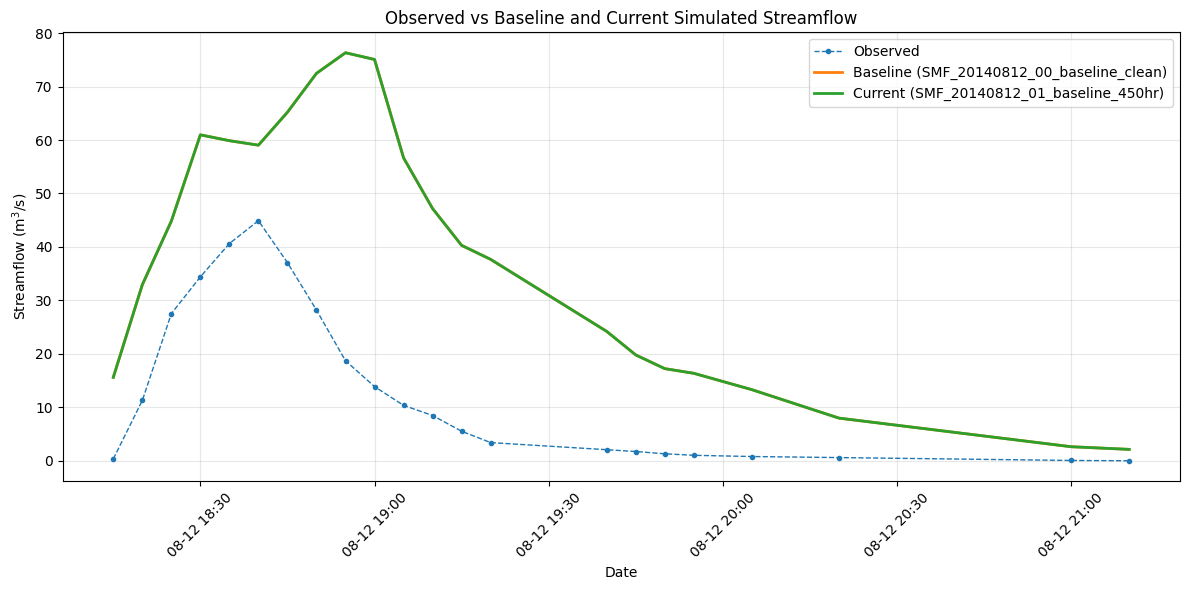

In [33]:
# What this cell does: plot observed and simulated hydrographs.

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    compare_runs.index,
    compare_runs["Observed"],
    label="Observed",
    linestyle="--",
    marker="o",
    markersize=3,
    linewidth=1
)

if not single_run_mode:
    ax.plot(
        compare_runs.index,
        compare_runs["Baseline"],
        label=f"Baseline ({baseline_run_id})",
        linewidth=2
    )

ax.plot(
    compare_runs.index,
    compare_runs["Current"],
    label=f"Current ({current_run_id})",
    linewidth=2
)

if single_run_mode:
    ax.set_title("Observed vs Current Simulated Streamflow")
else:
    ax.set_title("Observed vs Baseline and Current Simulated Streamflow")

ax.set_xlabel("Date")
ax.set_ylabel("Streamflow (m$^3$/s)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.xticks(rotation=45)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 7) Difference plot

This shows where the current run is higher or lower than the baseline run.


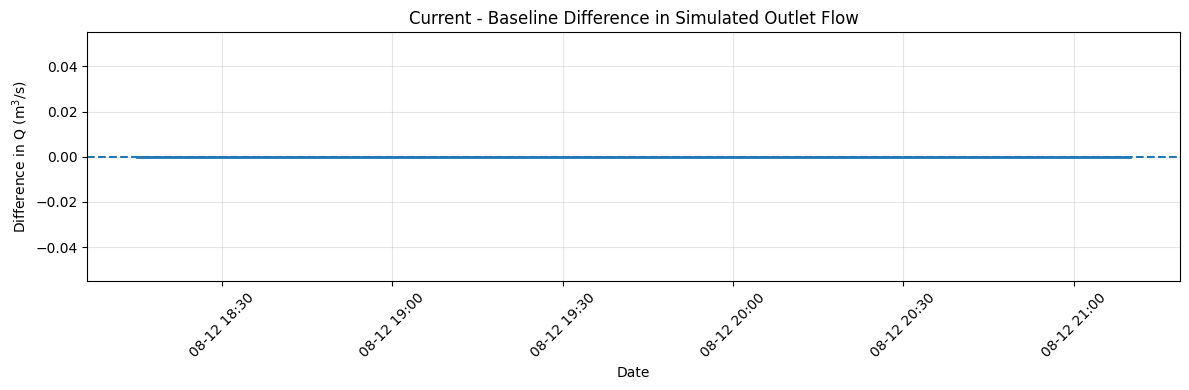

In [34]:
# What this cell does: plot current minus baseline simulated flow, if a baseline run exists.

if single_run_mode:
    print("Skipping current-minus-baseline plot because no baseline run was provided.")

else:
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(compare_runs.index, compare_runs["Current_minus_Baseline"], linewidth=2)
    ax.axhline(0, linestyle="--")

    ax.set_title("Current - Baseline Difference in Simulated Outlet Flow")
    ax.set_xlabel("Date")
    ax.set_ylabel("Difference in Q (m$^3$/s)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    plt.xticks(rotation=45)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8) Error plot against observed

This is useful because a run can be lower than baseline but still too high compared with observed.


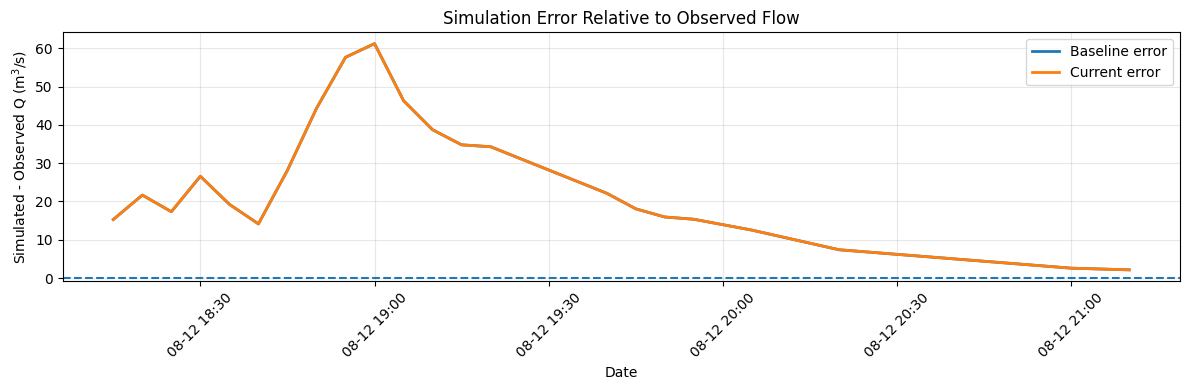

In [35]:
# What this cell does: plot simulation error relative to observed flow.

fig, ax = plt.subplots(figsize=(12, 4))

if not single_run_mode:
    ax.plot(
        compare_runs.index,
        compare_runs["Baseline"] - compare_runs["Observed"],
        label="Baseline error",
        linewidth=2
    )

ax.plot(
    compare_runs.index,
    compare_runs["Current"] - compare_runs["Observed"],
    label="Current error",
    linewidth=2
)

ax.axhline(0, linestyle="--")

ax.set_title("Simulation Error Relative to Observed Flow")
ax.set_xlabel("Date")
ax.set_ylabel("Simulated - Observed Q (m$^3$/s)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.xticks(rotation=45)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 9) Save outputs

This saves:
1. the aligned comparison table,
2. the metrics summary table.

These are the files you can use in your calibration log.


In [36]:
# What this cell does: save the aligned hydrograph table and metrics table for the calibration log.

if single_run_mode:
    comparison_name = f"{current_run_id}_single_run_aligned_comparison.csv"
    metrics_name = f"{current_run_id}_single_run_metrics_summary.csv"
else:
    comparison_name = f"{baseline_run_id}_vs_{current_run_id}_aligned_comparison.csv"
    metrics_name = f"{baseline_run_id}_vs_{current_run_id}_metrics_summary.csv"

comparison_path = summary_dir / comparison_name
metrics_path = summary_dir / metrics_name

compare_runs.to_csv(comparison_path, index=True)
metrics_with_delta.to_csv(metrics_path, index=False)

print("Saved aligned comparison:", comparison_path)
print("Saved metrics summary:   ", metrics_path)

Saved aligned comparison: ../../03_comparisons/summary_tables/SMF_20140812_00_baseline_clean_vs_SMF_20140812_01_baseline_450hr_aligned_comparison.csv
Saved metrics summary:    ../../03_comparisons/summary_tables/SMF_20140812_00_baseline_clean_vs_SMF_20140812_01_baseline_450hr_metrics_summary.csv


## 10) BEFORE RUNNING: Fill in data in this cell for master log and set to True

In [ ]:
# What this cell does: optionally append the current run's metrics to a master calibration log.

append_to_calibration_log = False  # Change to True only when you want to add this run to the log.

log_path = summary_dir / "SMF_20140812_calibration_log.csv"

if not append_to_calibration_log:
    print("Skipping calibration log update because append_to_calibration_log = False.")
    print("To add this run to the log, change append_to_calibration_log to True and rerun this cell.")

    if log_path.exists():
        existing_log = pd.read_csv(log_path)
        print("\nExisting calibration log preview:")
        display(existing_log.tail(10))
    else:
        print("\nNo calibration log exists yet.")

else:
    # In single-run mode, use the only metrics row.
    # In baseline-vs-current mode, use the "Current" row, not the delta row.
    if single_run_mode:
        run_metrics = metrics_with_delta.iloc[0].copy()
    else:
        run_metrics = metrics_with_delta[metrics_with_delta["Run"] == current_run_id].iloc[0].copy()

    # Add run metadata that will help you remember what changed.
    log_row = {
        "Logged At": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Run ID": current_run_id,
        "Baseline Run ID": baseline_run_id if baseline_run_id is not None else "",
        "Event Start": event_start,
        "Event End": event_end,

        # Fill these in manually before running the cell, or leave blank for now.
        "Change Category": "baseline/setup",       # examples: baseline, soil Ks, channel loss, routing
        "Knob Changed": "RUNTIME",          # examples: CHANNELCONDUCTIVITY, Ks multiplier, VELOCITYCOEF
        "Knob Value": "450 hr",            # examples: 200 mm/hr, 0.5x Ks, 1.2
        "Notes": "Longer runtime test; no change in 20140812 event metrics compared with clean baseline of 300 hours.",                 # quick interpretation
        "Decision": "neutral/setup test",                     # examples: keep, reject, neutral/setup test, rerun/check
    }

    # Add all metric columns from the compare notebook.
    for col, val in run_metrics.items():
        log_row[col] = val

    new_row = pd.DataFrame([log_row])

    if log_path.exists():
        old_log = pd.read_csv(log_path)
        updated_log = pd.concat([old_log, new_row], ignore_index=True)
    else:
        updated_log = new_row

    updated_log.to_csv(log_path, index=False)

    print("Updated calibration log:")
    print(log_path)

    display(updated_log.tail(10))

Updated calibration log:
../../03_comparisons/summary_tables/SMF_20140812_calibration_log.csv


,Logged At,Run ID,Baseline Run ID,Event Start,Event End,Change Category,Knob Changed,Knob Value,Notes,Decision,...,Observed Peak Time,Simulated Peak Time,Peak Timing Error (hours),Observed Volume (m3),Simulated Volume (m3),Volume Error (m3),Volume Error / PBIAS (%),RMSE (m3/s),NSE,KGE
0,2026-05-01 09:26:09,SMF_20140812_01_baseline_450hr,SMF_20140812_00_baseline_clean,2014-08-12 16:00,2014-08-13 12:00,baseline/setup,RUNTIME,450 hr,Longer runtime test; no change in 20140812 eve...,neutral/setup test,...,2014-08-12 18:40:00,2014-08-12 18:55:00,0.25,87668.8128,254330.895,166662.0822,190.104185,29.886038,-3.095975,-1.015988
